In [1]:
import numpy as np
import os, sys 
import re
import ROOT
ROOT.gStyle.SetOptStat(0)
import array
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import glob
import pandas as pd

import matplotlib.pyplot as plt
from linearization import linearization
import read_relcal
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

Welcome to JupyROOT 6.28/10


In [2]:
def MaxArray():

	ROOT.gInterpreter.Declare("""
	double find_maximum(const ROOT::VecOps::RVec<double>& vec) {
        return *std::max_element(vec.begin(), vec.end());
}
	""")

MaxArray()

In [3]:
def MinArray():

	ROOT.gInterpreter.Declare("""
	double find_minimum(const ROOT::VecOps::RVec<double>& vec) {
        return *std::min_element(vec.begin(), vec.end());
}
	""")

MinArray()

In [4]:
fp = "/scratch/perry/" ## this is the global file path the DMC data is saved in on compute canada

## Define the filepaths used
samples = "Ge71_Kshell_50V_QETabs"
#truth =   "/DMCOutput/Kshell_QETabs0.2_sidewallAnh1e-4v1_lowGammaPBCEF_*.root"
truth =   "/DMCOutput/Kshell_QETabs0.2_sidewallAnh1e-4v1_lowGammaPBCEF_*.root"

In [30]:
fp = "/project/6049244/share/SimData/DMC_SNOLAB_HV/"
samples = "Ge71_Kshell_pos50V_V05-09"
truth = "/DMCOutput/*.root"

In [31]:
## Get the file names in these folders
truthfiles = np.sort(glob.glob(fp+samples+truth))

In [32]:
config_path = "/scratch/perry/processing/cdmsbats_config/UserSettings/BatRootSettings/analysis/"
config = "DMCData.HV100mm_uni_triangle"
relcal_path = config_path+config

det = 1

In [33]:
df_TES = CDataFrame('G4SimDir/g4dmcTES', truthfiles)
df_TES_filtered = df_TES.Filter("DataType==0")

In [34]:
rel_calibs = read_relcal.get_rel_calib(relcal_path)

In [35]:
df_TES_filtered = df_TES_filtered.Define('MinHeight', 'find_minimum(Trace)')
df_TES_filtered = df_TES_filtered.Define('MaxHeight', 'find_maximum(Trace)')

In [36]:
TES = df_TES_filtered.AsNumpy(['EventNum', 'ChanName', 'MinHeight', 'MaxHeight'])

In [37]:
TES['Amp'] = np.array([(TES['MaxHeight'][i] - TES['MinHeight'][i])*rel_calibs[det][TES['ChanName'][i]] for i in range(len(TES['EventNum']))])

In [38]:
PFsum = TES['Amp'][TES['ChanName'] == 'PFS1'] + TES['Amp'][TES['ChanName'] == 'PFS2']
PAsum = TES['Amp'][TES['ChanName'] == 'PAS1'] + TES['Amp'][TES['ChanName'] == 'PAS2']
PEsum = TES['Amp'][TES['ChanName'] == 'PES1'] + TES['Amp'][TES['ChanName'] == 'PES2']
PDsum = TES['Amp'][TES['ChanName'] == 'PDS1'] + TES['Amp'][TES['ChanName'] == 'PDS2']
PCsum = TES['Amp'][TES['ChanName'] == 'PCS1'] + TES['Amp'][TES['ChanName'] == 'PCS2']
PBsum = TES['Amp'][TES['ChanName'] == 'PBS1'] + TES['Amp'][TES['ChanName'] == 'PBS2']
PT = np.array([sum(TES['Amp'][TES['EventNum'] == event]) for event in np.unique(TES['EventNum'])])

In [39]:
RadialPar_sim = (PFsum - PAsum) / PT

In [40]:
RadialPar_data = np.load('RadialPar_data_Ge71.npy')
PFsum_data = np.load('PFsum_data_Ge71.npy')
PAsum_data = np.load('PAsum_data_Ge71.npy')
PBsum_data = np.load('PBsum_data_Ge71.npy')
PCsum_data = np.load('PCsum_data_Ge71.npy')
PDsum_data = np.load('PDsum_data_Ge71.npy')
PEsum_data = np.load('PEsum_data_Ge71.npy')
PT_data = np.load('PTOFamps_data_Ge71.npy')

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


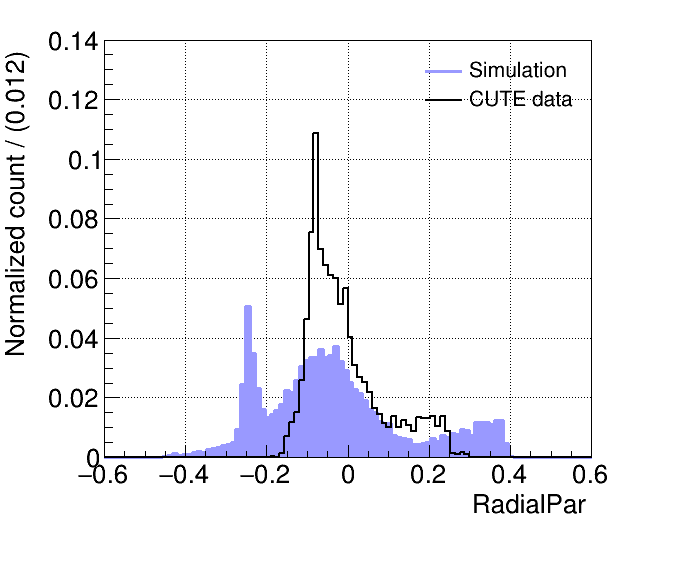

In [41]:
bins_start, bins_end, nbins = -0.6, 0.6, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.14)

hist.createHist(RadialPar_sim, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation", scale=len(RadialPar_sim))
hist.createHist(RadialPar_data, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, label="CUTE data", scale=len(RadialPar_data))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


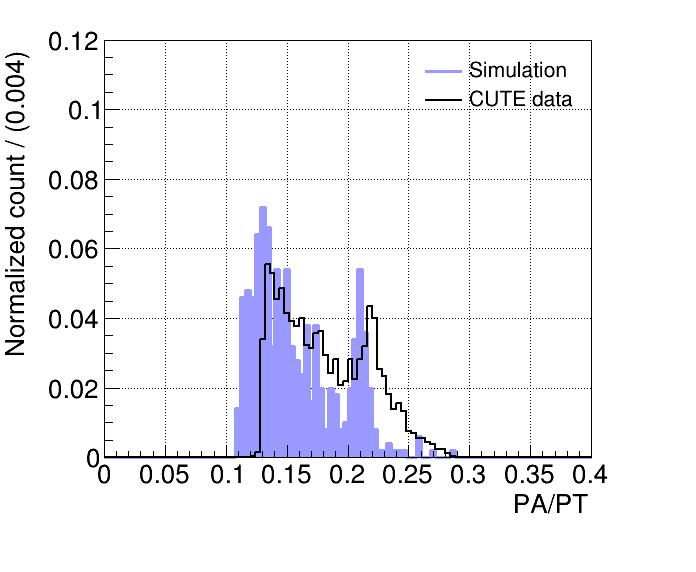

In [16]:
bins_start, bins_end, nbins = 0, 0.4, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="PA/PT", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.12)

hist.createHist(PAsum/PT, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation", scale=len(RadialPar_sim))
hist.createHist(PAsum_data/PT_data, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, label="CUTE data", scale=len(RadialPar_data))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


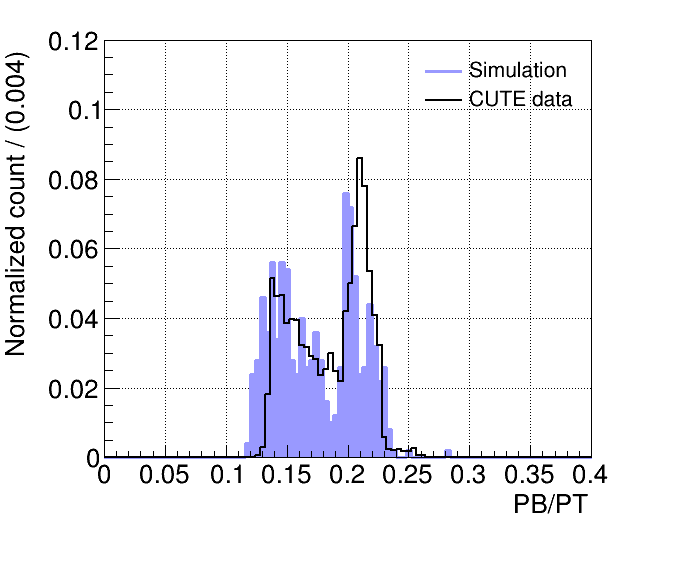

In [17]:
bins_start, bins_end, nbins = 0, 0.4, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="PB/PT", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.12)

hist.createHist(PBsum/PT, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation", scale=len(RadialPar_sim))
hist.createHist(PBsum_data/PT_data, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, label="CUTE data", scale=len(RadialPar_data))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


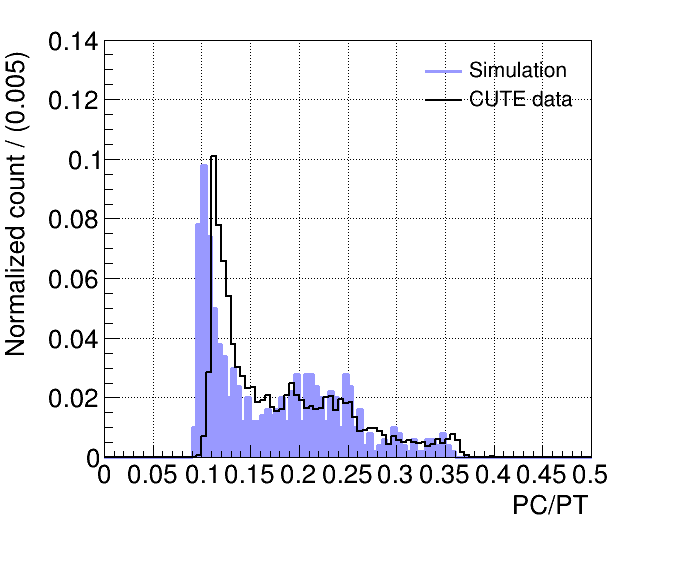

In [18]:
bins_start, bins_end, nbins = 0, 0.5, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="PC/PT", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.14)

hist.createHist(PCsum/PT, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation", scale=len(RadialPar_sim))
hist.createHist(PCsum_data/PT_data, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, label="CUTE data", scale=len(RadialPar_data))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


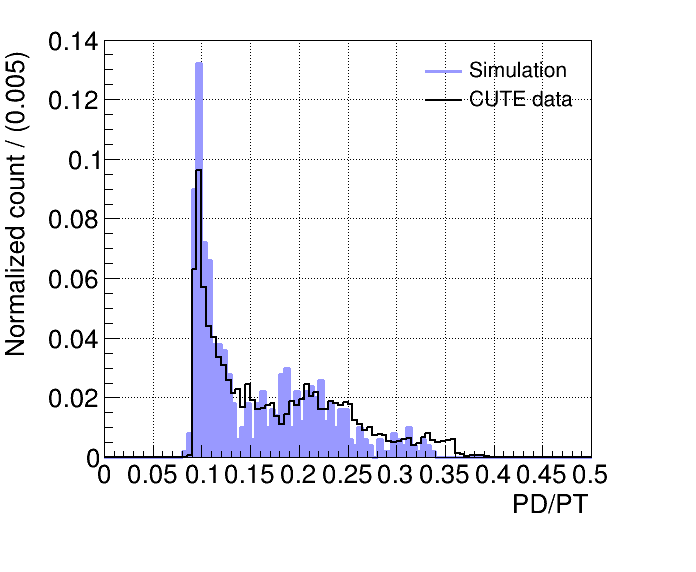

In [19]:
bins_start, bins_end, nbins = 0, 0.5, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="PD/PT", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.14)

hist.createHist(PDsum/PT, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation", scale=len(RadialPar_sim))
hist.createHist(PDsum_data/PT_data, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, label="CUTE data", scale=len(RadialPar_data))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


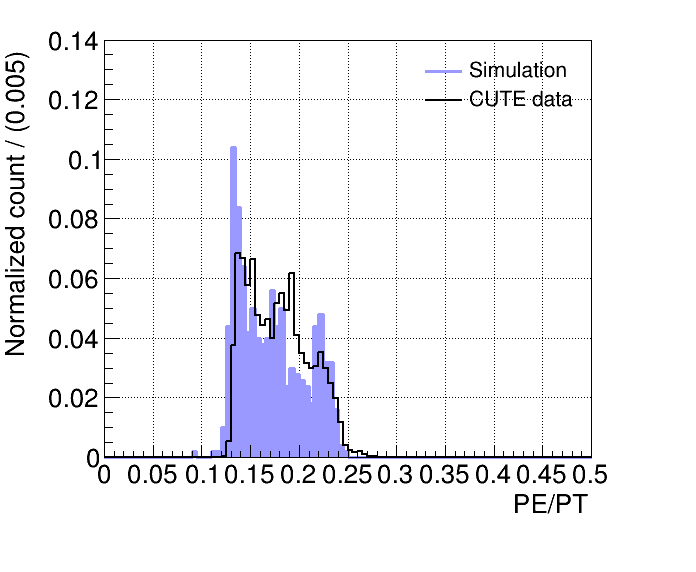

In [20]:
bins_start, bins_end, nbins = 0, 0.5, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="PE/PT", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.14)

hist.createHist(PEsum/PT, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation", scale=len(RadialPar_sim))
hist.createHist(PEsum_data/PT_data, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, label="CUTE data", scale=len(RadialPar_data))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


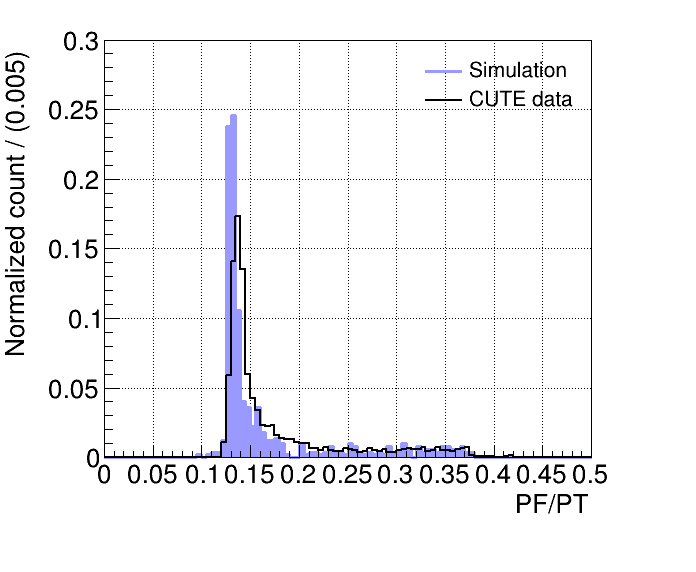

In [21]:
bins_start, bins_end, nbins = 0, 0.5, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="PF/PT", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.3)

hist.createHist(PFsum/PT, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation", scale=len(RadialPar_sim))
hist.createHist(PFsum_data/PT_data, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, label="CUTE data", scale=len(RadialPar_data))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


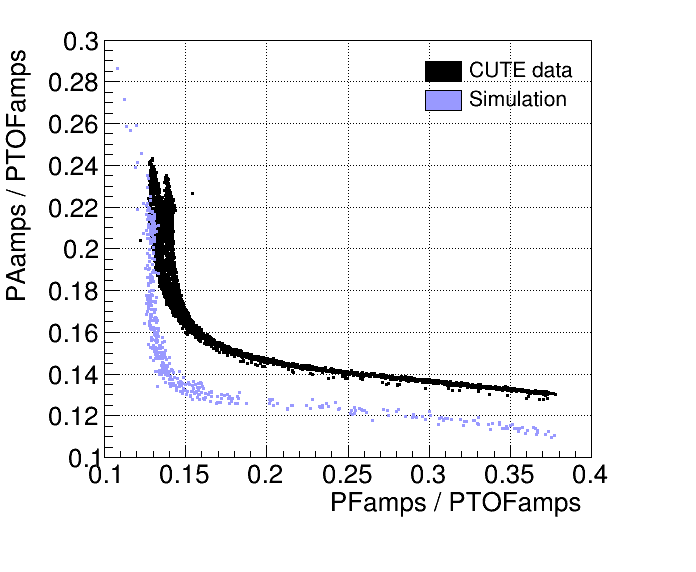

In [25]:
scatter_sim = ROOplot(700, 600, _xlabel="PFamps / PTOFamps", _ylabel="PAamps / PTOFamps", _xlim=True, _xlow=0.1, _xhigh=0.4, _ylim=True, _ylow=0.1, _yhigh=0.3)

scatter_sim.createScatter(PFsum_data/PT_data, PAsum_data/PT_data, color = ROOT.kBlack, size = 0.4, label = "CUTE data")
scatter_sim.createScatter(PFsum/PT, PAsum/PT, color = ROOT.kBlue-9, size = 0.4, label = "Simulation")
scatter_sim.draw("AP", "P ", grid=True)

graphs = scatter_sim.getGraphs()

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


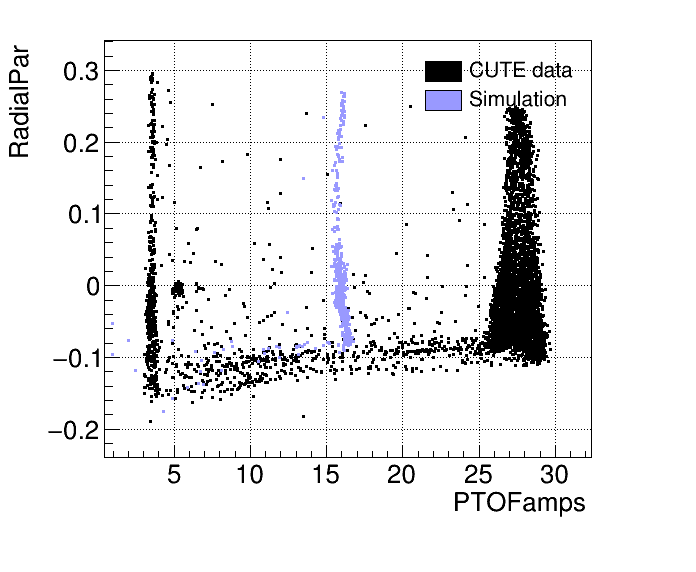

In [23]:
scatter_sim = ROOplot(700, 600, _xlabel="PTOFamps", _ylabel="RadialPar")

scatter_sim.createScatter(PT_data*1e6, (PFsum_data - PAsum_data)/PT_data, color = ROOT.kBlack, size = 0.4, label = "CUTE data")
scatter_sim.createScatter(PT, (PFsum - PAsum)/PT, color = ROOT.kBlue-9, size = 0.4, label = "Simulation")
scatter_sim.draw("AP", "P ", grid=True)

graphs = scatter_sim.getGraphs()

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

In [24]:
RadialPar_data = np.load('RadialPar_data_K.npy')
PFsum_data = np.load('PFsum_data_K.npy')
PAsum_data = np.load('PAsum_data_K.npy')
PBsum_data = np.load('PBsum_data_K.npy')
PCsum_data = np.load('PCsum_data_K.npy')
PDsum_data = np.load('PDsum_data_K.npy')
PEsum_data = np.load('PEsum_data_K.npy')
PT_data = np.load('PTOFamps_data_K.npy')

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


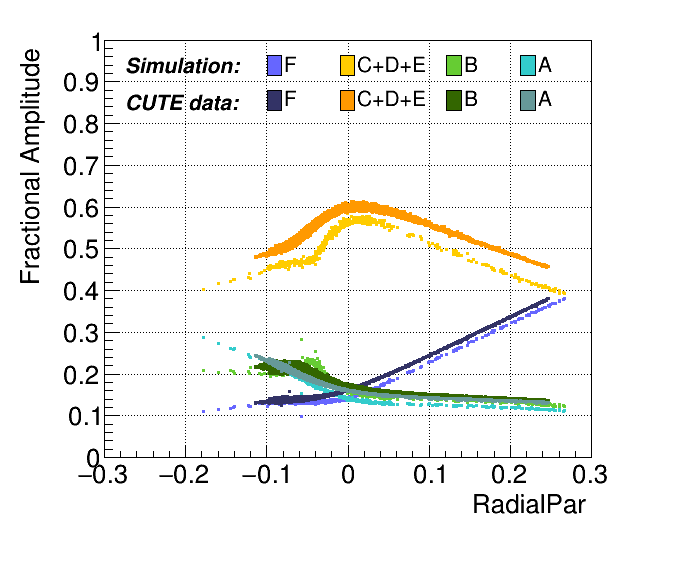

In [108]:
scatter_sim = ROOplot(700, 600, _xlabel="RadialPar", _ylabel="Fractional Amplitude", _ylim=True, _ylow=0, _yhigh=1, _xlim=True, _xlow=-0.3, _xhigh=0.3)

RadialPar = (PFsum - PAsum)/PT
wedgesum = PEsum + PCsum + PDsum
Bsum = PBsum
Asum = PAsum
Fsum = PFsum
PTOFamps = PT

scatter_sim.createScatter(RadialPar, (Fsum / PTOFamps), color = ROOT.kBlue-7, size = 0.4, label = "F" + " "*4)
scatter_sim.createScatter(RadialPar, (wedgesum / PTOFamps), color = ROOT.kOrange, size = 0.4, label = "C+D+E")
scatter_sim.createScatter(RadialPar, (Bsum / PTOFamps), color = ROOT.kSpring-5, size = 0.4, label = "B" + " "*4)
scatter_sim.createScatter(RadialPar, (Asum / PTOFamps), color = ROOT.kCyan-3, size = 0.4, label = "A" + " "*4)

RadialPar = (PFsum_data - PAsum_data)/PT_data
wedgesum = PEsum_data + PCsum_data + PDsum_data
Bsum = PBsum_data
Asum = PAsum_data
Fsum = PFsum_data
PTOFamps = PT_data

scatter_sim.createScatter(RadialPar, (Fsum / PTOFamps), color = ROOT.kBlue-1, size = 0.4, label = "F" + " "*4)
scatter_sim.createScatter(RadialPar, (wedgesum / PTOFamps), color = ROOT.kOrange-3, size = 0.4, label = "C+D+E")
scatter_sim.createScatter(RadialPar, (Bsum / PTOFamps), color = ROOT.kSpring-7, size = 0.4, label = "B" + " "*4)
scatter_sim.createScatter(RadialPar, (Asum / PTOFamps), color = ROOT.kCyan-5, size = 0.4, label = "A" + " "*4)


scatter_sim.draw("AP", "P ", grid=True)

graphs = scatter_sim.getGraphs()

legend1 = ROOT.TLegend(0.38, 0.86, 0.85, 0.91)
legend1.SetBorderSize(0)
legend1.SetFillStyle(0)
legend1.SetTextSize(0.04)
legend1.SetNColumns(4)
for g, label in graphs[:4]:
    legend1.AddEntry(g, label, "f")

legend2 = ROOT.TLegend(0.38, 0.8, 0.85, 0.85)
legend2.SetBorderSize(0)
legend2.SetFillStyle(0)
legend2.SetTextSize(0.04)
legend2.SetNColumns(4)
for g, label in graphs[4:]:
    legend2.AddEntry(g, label, "f")

legend1.Draw()
legend2.Draw()

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.04)
latex.SetTextAlign(13)
text = "#font[72]{Simulation:}"
latex.DrawLatex(0.18, 0.9, text)

text = "#font[72]{CUTE data:}"
latex.DrawLatex(0.18, 0.835, text)